# Chapter 14 — Zero-shot tabular foundation models

*Companion notebook to **The Learned Kernel**, Ch. 14. Run top to bottom.*

Read through the kernel lens, TabPFN and TabICL do **amortized Bayesian inference**: trained on a
synthetic prior to imitate its posterior predictive, a forward pass at deployment predicts an unseen
table with no fit. The white-box spectral emitter (Ch. 12-13) does the same inference but emits an
**interpretable kernel** instead of a label. Frozen on a new table it competes with fitted models
**where the data resemble a draw from the prior**; where it trails, the cause is **prior↔reality
mismatch** — readable in the emitted measure, fixable in the prior, not a failure of the meta-learner.

**Note.** Absolute zero-shot numbers on small tables are seed-noisy; the robust readings are the
*pattern* (competitive where the prior matches, gap on interaction-heavy California) and the *probe*
(the gap is the prior).

## Setup (GPU strongly recommended)

In [1]:
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from lkbook import set_style
from lkbook.chapters import ch14

set_style()
device = ch14._device()
print("device:", device)

device: cuda


## 14.1  A frozen emitter, zero-shot on real tables

Train **one** width-32 emitter on the broadened synthetic prior, freeze it, and predict three real
datasets from their training split as context alone — no gradient steps — against a per-dataset
fitted kernel machine (Ch. 8) and gradient boosting (CatBoost). Standardize, pad to width 32 with a
mask, emit a measure, decode.

In [3]:
net = ch14.train_zeroshot_emitter(d_max=32, steps=4000, seed=1, device=device)
table = ch14.zeroshot_table(net, datasets=("diabetes", "breast_cancer", "california"), d_max=32,
                            seed=1, device=device)
for n, d in table.items():
    z = d["zeroshot"]
    extra = f" AUC {z['auc']:.3f}" if d["kind"] == "clf" else ""
    print(f"{n:14s} zero-shot {z['score']:.3f}{extra}   fitted KM {d['ch8']['score']:.3f}   "
          f"CatBoost {d['catboost']['score']:.3f}")

diabetes       zero-shot 0.230   fitted KM 0.293   CatBoost 0.309
breast_cancer  zero-shot 0.917 AUC 0.973   fitted KM 0.947   CatBoost 0.943
california     zero-shot 0.445   fitted KM 0.814   CatBoost 0.827


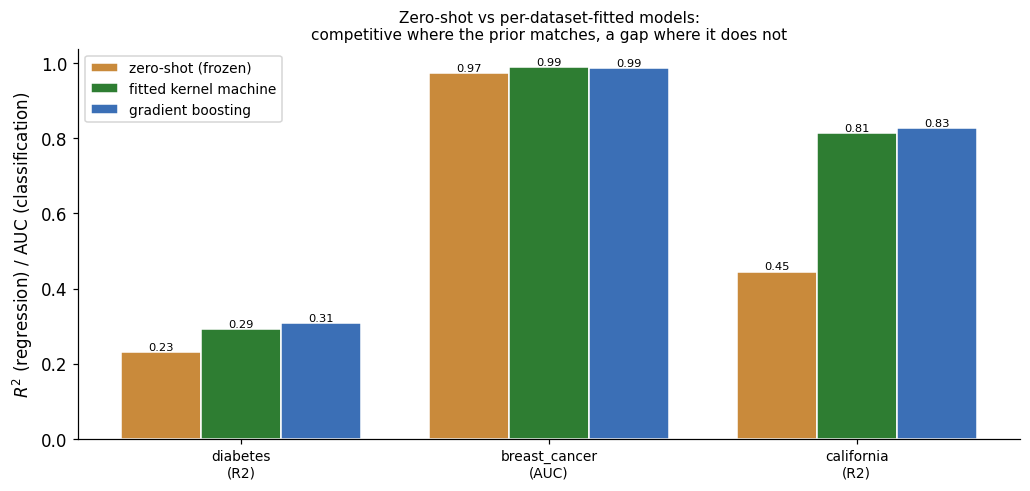

In [4]:
ch14.make_zeroshot_figure(table)
plt.show()

Competitive where the data resemble a draw from the prior (breast-cancer, diabetes), a clear gap on
**California** — which rewards feature interactions (geography, ratios of counts) that the smooth,
largely additive synthetic prior does not carry.

## 14.2  Diagnosing the gap: the meta-learner or the prior?

Two readings, opposite responses. Either the emitter **cannot** map a context to a
California-fitting kernel (meta-learner limit) or it **can** but was never trained on
California-like tasks (prior limit). The probe: meta-train the **same** architecture on resamples of
the California training split (real labels, no test-time fitting) and evaluate on the held-out test.

In [5]:
lever = ch14.context_lever(net, d_max=32, seed=1, device=device)   # also the context curve below
probe = ch14.probe_california(lever[512], steps=3000, seed=1, device=device)
print(f"synthetic prior, zero-shot      R2 = {probe['synthetic']:.3f}")
print(f"in-context on California         R2 = {probe['in_context_real_2048']:.3f}")
print(f"fitted kernel machine (ceiling) R2 = {probe['ch8_ceiling']:.3f}")
print(f"gradient boosting               R2 = {probe['catboost']:.3f}")

synthetic prior, zero-shot      R2 = 0.445
in-context on California         R2 = 0.810
fitted kernel machine (ceiling) R2 = 0.804
gradient boosting               R2 = 0.833


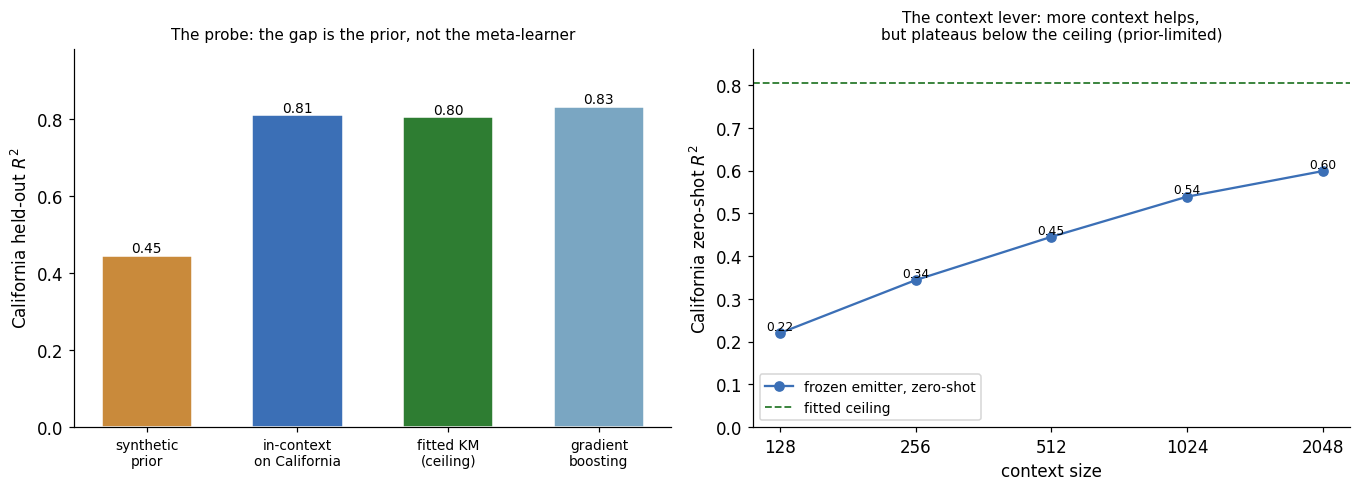

In [6]:
ch14.make_probe_figure(probe, lever)
plt.show()

The in-context-on-California emitter reaches the fitted ceiling; the synthetic-prior emitter does
not. **The gap is the prior, not the meta-learner** — the architecture can express California, it
was just never shown California-like structure. And it is *readable*: the emitted relevances below
show which geometry the synthetic prior produced.

The **context lever** (right panel) rises with the subsample but **plateaus below the ceiling** — so
the residual is the prior's functional class (too smooth/additive), not the amount of data.

## 14.3  Reading the emitted measure

The emitted ARD relevances are the diagnostic: a near-uniform, smooth profile on an interaction-heavy
table is the visible signature of prior mismatch.

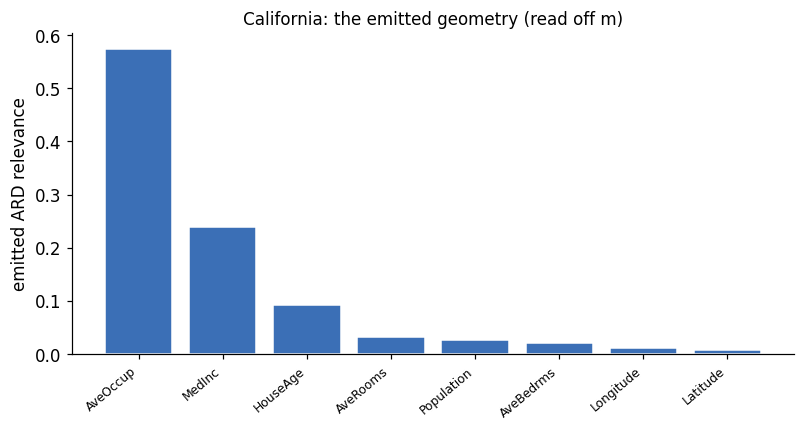

In [7]:
names, rel = ch14.read_relevances(net, dataset="california", d_max=32, seed=1, device=device)
order = np.argsort(rel)[::-1]
fig, ax = plt.subplots(figsize=(7.2, 3.8), constrained_layout=True)
ax.bar(range(len(rel)), rel[order], color="#3b6fb6", edgecolor="white")
ax.set_xticks(range(len(rel))); ax.set_xticklabels([names[i] for i in order], rotation=40, ha="right",
                                                    fontsize=8)
ax.set_ylabel("emitted ARD relevance"); ax.set_title("California: the emitted geometry (read off m)")
plt.show()

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(medium)** Confirm the probe contrast is robust to the synthetic number: re-run the probe and
check the in-context-on-California R² stays near the fitted ceiling and well above the synthetic.

In [8]:
# TODO: call ch14.probe_california at a couple seeds; compare in_context_real_2048 to ch8_ceiling.

<details><summary>Solution</summary>

```python
for s in (0, 1):
    pr = ch14.probe_california(0.4, steps=2000, seed=s, device=device)
    print(s, "in-context", round(pr["in_context_real_2048"], 3), "ceiling", round(pr["ch8_ceiling"], 3))
```
The in-context value tracks the ceiling across seeds; the synthetic number is the noisy one, which
is why the chapter rests on the *contrast*.
</details>

**(medium)** Show more context helps California but not the small datasets (whose splits already fit
within the cap).

In [9]:
# TODO: ch14.context_lever(net) for California; compare to a diabetes zero-shot at two context caps.

<details><summary>Solution</summary>

California rises with context and plateaus below the ceiling; diabetes is unchanged because its
training split is smaller than the context cap, so the context is already complete. The residual is
the prior's functional class, not the data budget.
</details>

**(⋆)** Decompose the zero-shot excess risk into the amortization gap (the Ch. 12 regret) plus a
prior-mismatch bias, and explain why the probe estimates the second term directly.

<details><summary>Solution</summary>

Excess risk ≤ regret_P(k) (amortization, measured under the prior P) + B(P,Q) (prior-mismatch bias,
the cost of using P's posterior mean on a Q-task). Re-training the same architecture on resamples of
Q (the probe) replaces P by Q, so the residual to the fitted ceiling collapses, isolating B(P,Q) as
the cause of the synthetic-prior gap. The route to closing it is a richer prior over a fixed
geometry, not a heavier emitter.
</details>